In [1]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("NFLX.csv")
df.isnull().sum()
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Train MAE: 2.9810, Train R2: 0.9980
Test MAE: 31.6962, Test R2: 0.7154
Graph saved as nflx_final_prediction_plot.png


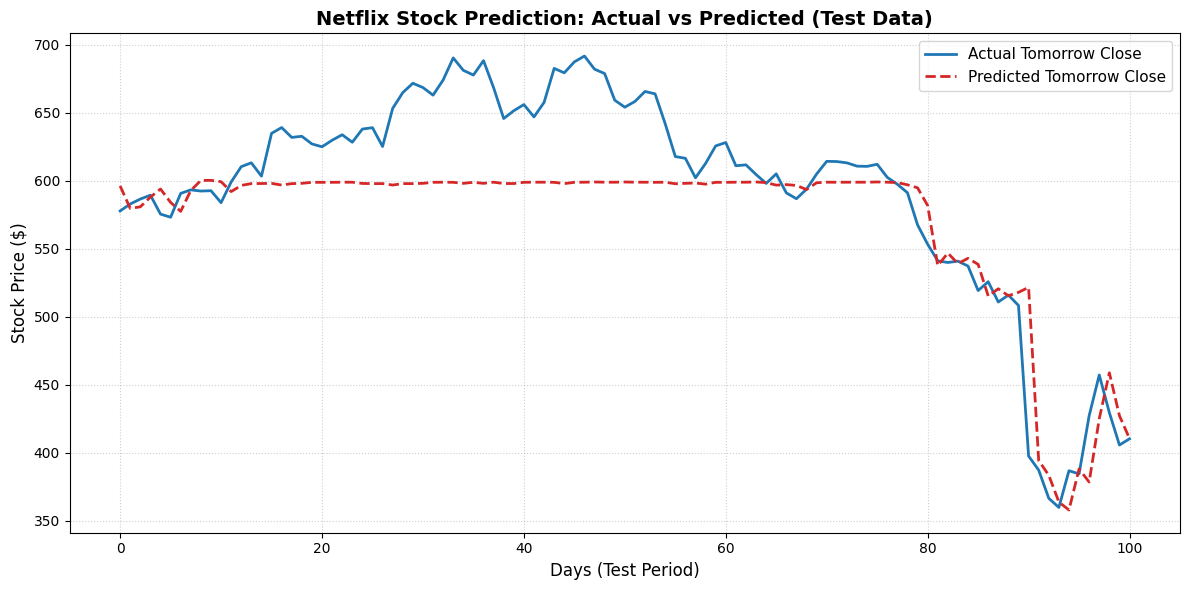

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Data load karein
df = pd.read_csv("NFLX.csv")

# 2. Target banayein
df['Tomorrow_Close'] = df['Close'].shift(-1)
df = df.dropna()

# 3. Features aur Target
X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['Tomorrow_Close']

# 4. Data Split (90% Train, 10% Test - as per user's updated code)
train_size = int(len(df) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 5. Model Training
model = RandomForestRegressor(n_estimators=102, random_state=42)
model.fit(X_train, y_train)

# 6. Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics for exact printout
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Train MAE: {mae_train:.4f}, Train R2: {r2_train:.4f}")
print(f"Test MAE: {mae_test:.4f}, Test R2: {r2_test:.4f}")

# Plotting graph
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_test.values, label='Actual Tomorrow Close', color='#1f77b4', linewidth=2)
ax.plot(y_test_pred, label='Predicted Tomorrow Close', color='#d62728', linestyle='--', linewidth=2)
ax.set_title('Netflix Stock Prediction: Actual vs Predicted (Test Data)', fontsize=14, fontweight='bold')
ax.set_xlabel('Days (Test Period)', fontsize=12)
ax.set_ylabel('Stock Price ($)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('nflx_final_prediction_plot.png')
print("Graph saved as nflx_final_prediction_plot.png")

In [77]:
import pickle

# Model ko 'netflix_model.pkl' naam ki file mein save karein
with open('netflix_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("🚀 Model successfully saved as netflix_model.pkl!")

🚀 Model successfully saved as netflix_model.pkl!
